<h1 style="text-align:center;"><b>Laboratorio 4</b></h1>
<h3 style="text-align:center;">Marcos Díaz (221102), Daniel Machic (22118), Maria Jose Ramírez (221051)</h3>

**GitHub**: https://github.com/mac2218/IA-Lab04.git

# **Problema 3 – Traveling Salesman Problem (TSP)**

## **Espacio de configuraciones**
Sea un grafo completo $G = (V,E)$ con:
- $V| = n$ ciudades
- $c(i,j)$ el costo (distancia) entre ciudades $i$ y $j$

El objetivo es encontrar un ciclo Hamiltoniano de costo mínimo.


## **El tamaño de $Ω$**
El espacio de búsqueda está formado por todas las rutas posibles que:
1. Empiezan en una ciudad fija (sin pérdida de generalidad, la ciudad 1)
2.	Visitan cada ciudad exactamente una vez
3.	Regresan a la ciudad inicial

Por lo tanto, $\Omega = \{ \text{todas las permutaciones de las } n-1 \text{ ciudades restantes} \}$

Cada configuración representa un ciclo Hamiltoniano.
## **Descripción de las configuraciones**
Si fijamos la ciudad inicial para evitar soluciones equivalentes por rotación:

$$|\Omega| = (n-1)!$$

Si además el grafo es no dirigido (la ruta inversa es equivalente):

$$|\Omega| = \frac{(n-1)!}{2}$$

El crecimiento es factorial, lo que explica que el problema sea NP-Hard.

## **Métrica o función de costo a optimizar para resolver el problema**
1. ### **Permutaciones (vector)**

    Una solución puede representarse como: $(1, v_2, v_3, \dots, v_n, 1)$

    Ejemplo para $n=4$:

    $(1,2,3,4,1)$


2. ### **Secuencia o arreglo**
    $[1, 3, 2, 4, 1]$


3. ### **Subgrafo**

    Un subgrafo que:
     
     - Contiene todos los nodos
     - Cada nodo tiene grado 2
     - Forma un ciclo cerrado



4. ### **Función de costo a optimizar**

    La función objetivo es minimizar el costo total del recorrido:

     $f(\pi) = \sum_{i=1}^{n-1} c(v_i, v_{i+1}) + c(v_n, v_1)$

    Donde:
     - $\pi$ es una permutación de ciudades
     - $c(i,j)$ es el costo entre ciudades

    El objetivo es: 
    $\min_{\pi \in \Omega} f(\pi)$

5. ## **Gráfica del árbol de búsqueda**
    Ejemplo con $n = 4$ ciudades: ${1,2,3,4}$

    Fijamos inicio en $1$.    



### Nivel 0 (raíz)

In [ ]:
# (1)

1

### Nivel 1

In [4]:
#                 (1)
#            /       |       \
#        (1,2)    (1,3)    (1,4)

### Nivel 2

Desde (1,2):

In [6]:
#    (1,2)
#   /     \
#(1,2,3) (1,2,4)

Desde (1,3):

In [7]:
#     (1,3)
#    /     \
#(1,3,2) (1,3,4)

Desde (1,4):

In [8]:
#    (1,4)
#   /     \
#(1,4,2) (1,4,3)

# **Ejercicio 4 - Sudoku 9x9**

#### **Espacio de configuraciones $\Omega$**

El espacio de configuraciones $\Omega$ corresponde al conjunto de **todas las posibles asignaciones de números en las casillas del tablero de Sudoku**, respetando los valores iniciales dados en el problema. Cada configuración representa **un estado del tablero**, que puede estar parcial o completamente lleno.

$$
\Omega = \{ X \in \{1,\dots,9\}^{9\times9} \}
$$

donde cada elemento $X$ es una matriz $9\times9$ cuyos valores pertenecen al conjunto $\{1,2,\dots,9\}$. En el caso del Sudoku, algunas posiciones del tablero están **fijadas inicialmente** y no pueden modificarse durante la búsqueda.

#### **Tamaño del espacio de búsqueda**

Si el tablero tiene $k$ casillas vacías, y cada una puede tomar un valor entre 1 y 9, entonces el número total de configuraciones posibles es:

$$
|\Omega| = 9^k
$$

En un Sudoku típico, aproximadamente la mitad de las casillas están vacías, por lo que el tamaño del espacio de búsqueda puede ser extremadamente grande. Esto hace necesario el uso de algoritmos de búsqueda con restricciones, como el backtracking.

#### **Descripción de las configuraciones**

Cada configuración del problema puede representarse mediante una **matriz $9\times9$**:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} & ... & x_{19} \\
x_{21} & x_{22} & ... & x_{29} \\
\vdots & \vdots & \ddots & \vdots \\
x_{91} & x_{92} & ... & x_{99}
\end{bmatrix}
$$

donde

$$
x_{ij} \in \{1,2,\dots,9\}
$$

Cada estado corresponde a una posible configuración del tablero durante el proceso de búsqueda. Las configuraciones deben cumplir con las restricciones del Sudoku:

- No repetir números en cada fila.
- No repetir números en cada columna.
- No repetir números en cada subcuadrícula $3\times3$.

## Función de costo

La función de costo permite medir qué tan lejos se encuentra una configuración de ser una solución válida. Una posible definición de la función de costo es contar el número de violaciones de las reglas del Sudoku:

- repeticiones en filas  
- repeticiones en columnas  
- repeticiones en subcuadrículas $3\times3$

El problema consiste en encontrar una configuración $X$ que minimice esta función:

$$
\min cost(X)
$$

Cuando se cumple que

$$
cost(X) = 0
$$

significa que no existen violaciones de las reglas del Sudoku y, por lo tanto, el tablero corresponde a una solución válida.

## Gráfica de árbol de búsqueda

- El nodo raíz representa el tablero inicial del Sudoku.
- Cada nivel del árbol corresponde a la asignación de un valor a una casilla vacía.
- Cada rama representa una posible elección de un número entre 1 y 9.

Por ejemplo, si la primera casilla vacía puede tomar los valores 1, 2 o 3, el árbol comenzaría de la siguiente forma:

Estado inicial  
├── $x_1 = 1$  
│   ├── $x_2 = 1$  
│   ├── $x_2 = 2$  
│   └── $x_2 = 3$  
├── $x_1 = 2$  
│   ├── $x_2 = 1$  
│   ├── $x_2 = 2$  
│   └── $x_2 = 3$  
└── $x_1 = 3$  
    ├── $x_2 = 1$  
    ├── $x_2 = 2$  
    └── $x_2 = 3$

Cada nodo representa un estado parcial del tablero, y el algoritmo de búsqueda explora este árbol hasta encontrar una configuración que satisfaga todas las restricciones del Sudoku.

# **Ejercicio 5**

Número de nodos: 34
Número de aristas: 78


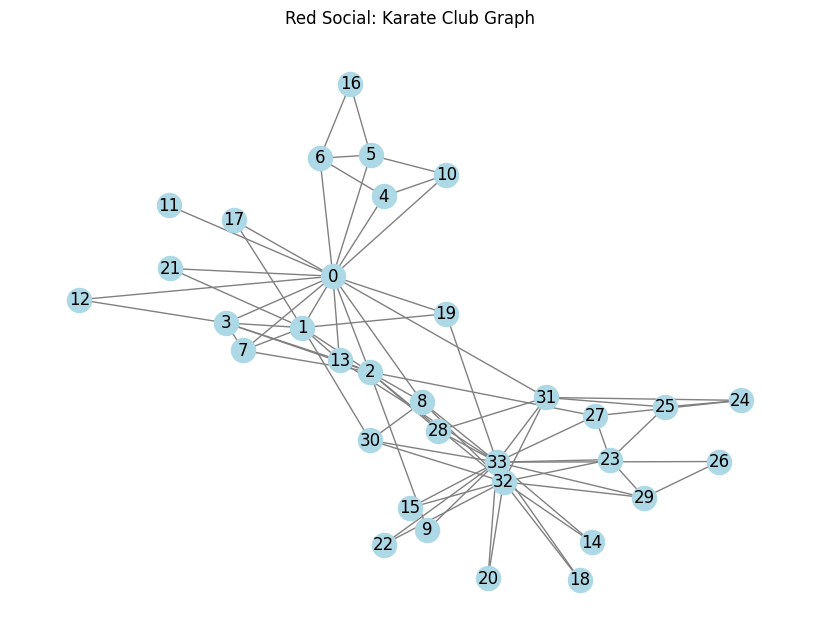

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# (a) Cargar el grafo
G = nx.karate_club_graph()

# (b) Numero de nodos
num_nodes = G.number_of_nodes()

# Numero de aristas
num_edges = G.number_of_edges()

print("Número de nodos:", num_nodes)
print("Número de aristas:", num_edges)

# Grafo
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray")
plt.title("Red Social: Karate Club Graph")
plt.show()

**Métricas para identificar un “influencer” en una red social**

1. Degree Centrality
Esta métrica mide cuántas conexiones directas tiene un nodo con otros nodos en la red. Un nodo con un alto degree centrality está conectado con muchos otros, por lo que puede influir directamente sobre más individuos dentro de la red. Es una de las métricas más simples y representa la popularidad o conectividad directa de un nodo.

2. Betweenness Centrality 
Esta métrica mide cuántas veces un nodo aparece en los caminos más cortos entre otros pares de nodos. Un nodo con alta betweenness centrality actúa como un puente o intermediario dentro de la red, controlando el flujo de información entre diferentes partes de la red. Estos nodos pueden ser críticos para conectar comunidades o grupos.

3. Closeness Centrality 
Esta métrica mide qué tan cerca está un nodo del resto de los nodos de la red considerando la distancia mínima entre ellos. Un nodo con alta closeness centrality puede difundir información rápidamente al resto de la red, ya que necesita pasar por menos intermediarios para llegar a los demás nodos.

Top Influencer según Degree Centrality: 33
Top Influencer según Betweenness Centrality: 0
Top Influencer según Closeness Centrality: 0


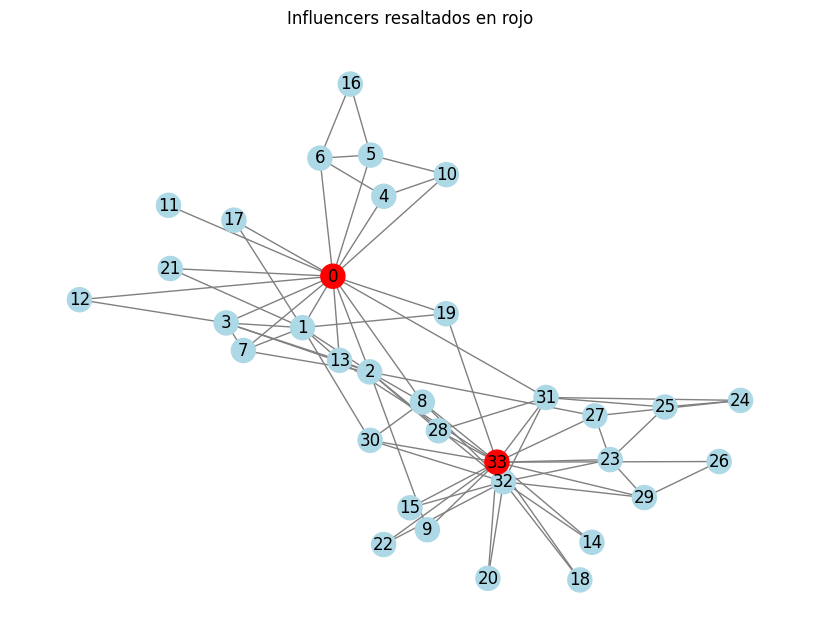


Comunidades encontradas:
Comunidad 1: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] | Tamaño: 17
Comunidad 2: [1, 2, 3, 7, 9, 12, 13, 17, 21] | Tamaño: 9
Comunidad 3: [0, 16, 19, 4, 5, 6, 10, 11] | Tamaño: 8

Comunidades de tamaño 3, 4 y 5 o más:
[8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] Tamaño: 17
[1, 2, 3, 7, 9, 12, 13, 17, 21] Tamaño: 9
[0, 16, 19, 4, 5, 6, 10, 11] Tamaño: 8


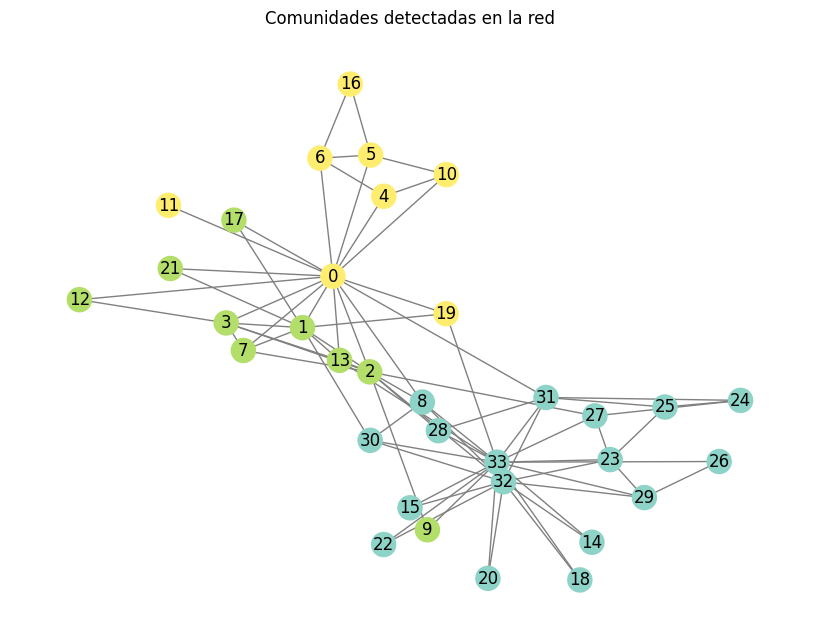

In [2]:
# (d) Calcular métricas de centralidad
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Encontrar el Top Influencer según cada métrica
top_degree = max(degree_centrality, key=degree_centrality.get)
top_betweenness = max(betweenness_centrality, key=betweenness_centrality.get)
top_closeness = max(closeness_centrality, key=closeness_centrality.get)

print("Top Influencer según Degree Centrality:", top_degree)
print("Top Influencer según Betweenness Centrality:", top_betweenness)
print("Top Influencer según Closeness Centrality:", top_closeness)

# Visualizar el grafo resaltando los influencers
colors = []
for node in G.nodes():
    if node in [top_degree, top_betweenness, top_closeness]:
        colors.append("red")
    else:
        colors.append("lightblue")

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=colors, edge_color="gray")
plt.title("Influencers resaltados en rojo")
plt.show()


# (e) Identificación de comunidades usando partición codiciosa 
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

print("\nComunidades encontradas:")
for i, com in enumerate(communities):
    print(f"Comunidad {i+1}: {list(com)} | Tamaño: {len(com)}")

print("\nComunidades de tamaño 3, 4 y 5 o más:")
for com in communities:
    if len(com) >= 3:
        print(list(com), "Tamaño:", len(com))


# Visualización de comunidades
node_colors = {}
for i, com in enumerate(communities):
    for node in com:
        node_colors[node] = i

colors = [node_colors[node] for node in G.nodes()]

plt.figure(figsize=(8,6))
nx.draw(G, pos, with_labels=True, node_color=colors, cmap=plt.cm.Set3, edge_color="gray")
plt.title("Comunidades detectadas en la red")
plt.show()

Los resultados muestran que los nodos 0 y 33 juegan un papel importante dentro de la red. El nodo 33 aparece como el Top Influencer según Degree Centrality, lo que significa que es el nodo con mayor número de conexiones directas dentro del grafo. En otras palabras, está conectado con muchos otros nodos, lo que lo vuelve muy relevante en términos de interacción directa. Por otro lado, el nodo 0 es identificado como el más influyente según Betweenness Centrality y Closeness Centrality. Esto indica que el nodo 0 actúa como un puente dentro de la red, apareciendo con frecuencia en los caminos más cortos entre otros nodos, además de estar relativamente cerca del resto de la red, lo que le permite transmitir información de manera eficiente.

En cuanto a la detección de comunidades, el algoritmo identificó tres grupos principales dentro de la red, con tamaños de 17, 9 y 8 nodos respectivamente. Esto sugiere que la red social no es completamente homogénea, sino que está estructurada en subgrupos donde los nodos tienen más conexiones entre sí que con el resto de la red. La comunidad más grande (17 nodos) representa un grupo con alta interconexión interna, mientras que las otras dos comunidades también muestran agrupaciones claras de usuarios.